In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.shape

(1338, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

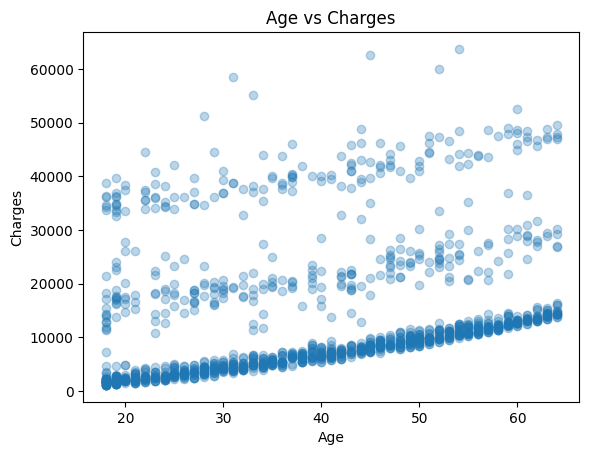

In [16]:
plt.scatter(df["age"], df["charges"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

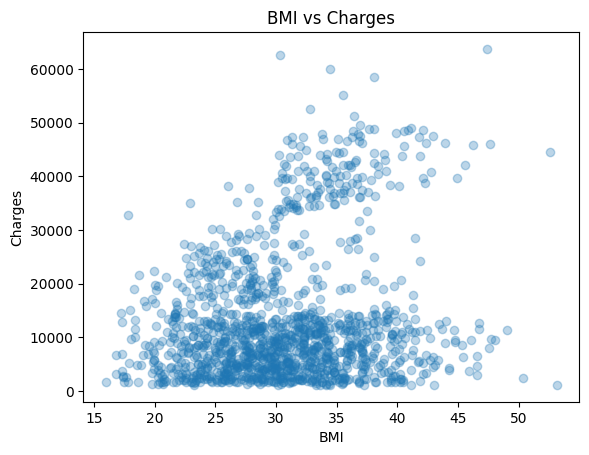

In [17]:
plt.scatter(df["bmi"], df["charges"], alpha=0.3)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.show()

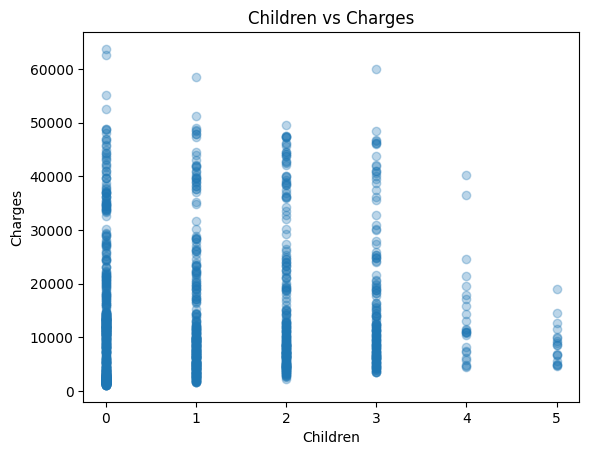

In [18]:
plt.scatter(df["children"], df["charges"], alpha=0.3)
plt.xlabel("Children")
plt.ylabel("Charges")
plt.title("Children vs Charges")
plt.show()

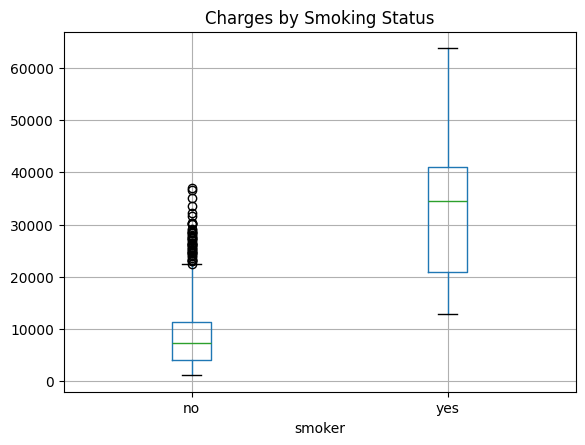

In [19]:
df.boxplot(column="charges", by="smoker")
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.show()

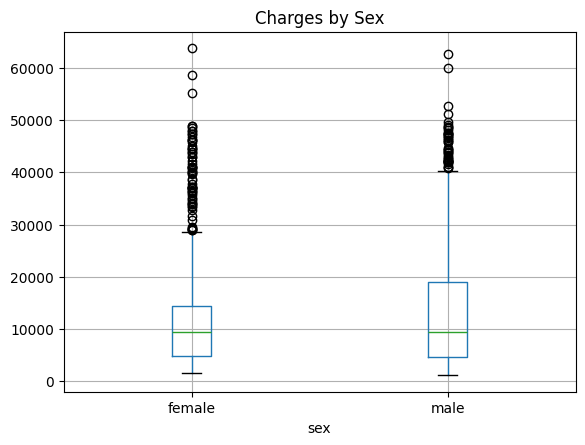

In [20]:
df.boxplot(column="charges", by="sex")
plt.title("Charges by Sex")
plt.suptitle("")
plt.show()

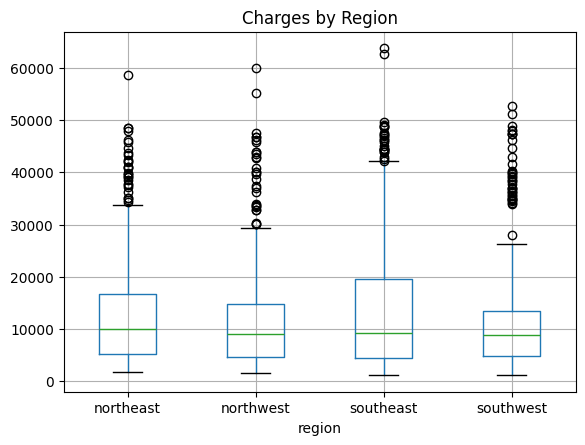

In [21]:
df.boxplot(column="charges", by="region")
plt.title("Charges by Region")
plt.suptitle("")
plt.show()

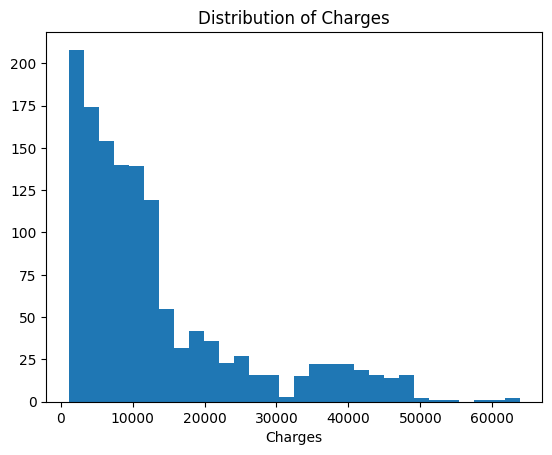

In [22]:
plt.hist(df["charges"], bins=30)
plt.xlabel("Charges")
plt.title("Distribution of Charges")
plt.show()


## Exploratory Analysis

**Age vs Charges**: There is a linear increase — as a person's age increases, their insurance 
charge goes up. Looking closer, the data actually seems to form three separate diagonal bands 
rather than one single line, all sloping upward with age. This suggests some other factor 
(likely smoking status) is splitting the data into these distinct groups.

**BMI vs Charges**: There appear to be two clusters — a large one at lower charges, and a 
smaller one above ~$30,000. This mirrors the pattern seen in Age vs Charges, suggesting some 
other factor (possibly smoking status) may be splitting the data into these two groups.

**Children vs Charges**: No clear trend visible — charges look similarly spread out regardless 
of number of children, so this feature may not be very predictive on its own.

**Charges by Smoking Status**: A clear and dramatic trend — smokers have noticeably higher 
charges (median around $34,000, box spanning ~$21,000-$41,000) compared to non-smokers (median 
around $7,000-8,000). This is likely the single strongest predictor in the dataset, and probably 
explains the clustering seen in the Age and BMI plots above.

**Charges by Sex**: No visible difference between the two boxes — sex likely has little to no 
effect on charges.

**Charges by Region**: All four regions look similar, with maybe a slightly higher spread in 
the southeast — no strong trend.

**Distribution of Charges**: Right-skewed — most people have charges under $10,000-15,000, 
with a smaller group extending out toward $20,000-60,000+.

In [30]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [32]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

trainX, valX, trainY, valY = train_test_split(X, y, test_size=0.25, random_state=8)

model = LinearRegression()
model.fit(trainX,trainY)

for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")
print("Intercept:", model.intercept_)

age: 254.62278635626146
bmi: 321.4419907194368
children: 415.9314998779928
sex_male: -200.21619080872028
smoker_yes: 24435.86823027013
region_northwest: -590.6649861056408
region_southeast: -1230.5201259670382
region_southwest: -1327.2356549274841
Intercept: -11011.826792293377


## Model Coefficients — Interpretation

After training, the model's coefficients confirm a lot of what the exploratory plots suggested:
- **smoker_yes (+24,436)**: by far the largest effect, smoking is associated with about 
  $24,436 higher charges, holding everything else constant. This matches the dramatic split 
  seen in the smoking status box plot.
- **age (+255)** and **bmi (+321)**: both positive and modest, consistent with the upward 
  trends seen in their scatter plots.
- **sex_male (-200)**: a very small effect, consistent with the nearly identical box plots 
  for sex.

Interestingly, a couple of coefficients revealed relationships that weren't obvious from the 
raw plots alone:
- **children (+416)**: the scatter plot showed no clear trend, but once other features are 
  held constant, more children is associated with modestly higher charges.
- **region coefficients (all negative relative to northeast)**: the box plots showed regions 
  looking fairly similar, but the model found real differences once other factors are 
  controlled for — southwest in particular is associated with meaningfully lower charges 
  than the northeast baseline.

This shows why checking model coefficients is a more rigorous step than relying on single-
variable plots alone — some relationships only become visible once other factors are 
accounted for.

The intercept (-11,012) doesn't have a meaningful real-world interpretation on its own, since 
it represents the prediction when every feature is 0 — a combination that doesn't occur in 
real data (nobody has age=0 or bmi=0).

In [34]:
val_preds = model.predict(valX)
val_mse = mean_squared_error(valY, val_preds)
val_mae = mean_absolute_error(valY, val_preds)
val_rmse = np.sqrt(val_mse)

print("Validation MSE:", val_mse)
print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)

Validation MSE: 34353129.52028558
Validation MAE: 4107.928637380519
Validation RMSE: 5861.154282245569


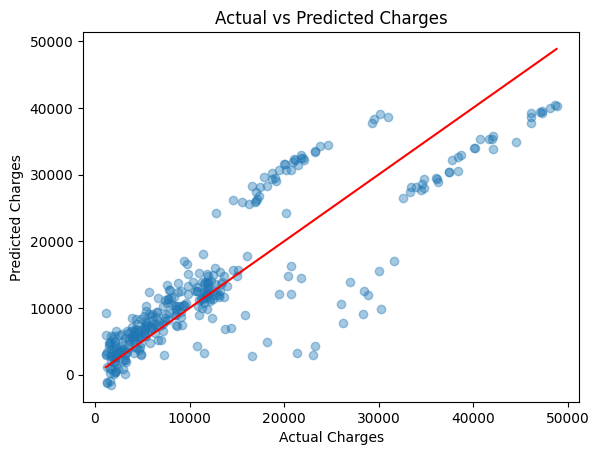

In [ ]:
plt.scatter(valY, val_preds, alpha=0.4)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.plot([valY.min(), valY.max()], [valY.min(), valY.max()], color="red")
plt.show()